In [ ]:
# ! pip install statsforecast hierarchicalforecast mlforecast utilsforecast

In [1]:
import pandas as pd
from matplotlib import pyplot as plt

# Carrega e prepara o dataset

## Carrega os dados

In [24]:
data = pd.read_csv('data.csv')
data['ds'] = pd.to_datetime(data['data_epi'])
data = data[data.ds < '2026-01-01']
data

,data_epi,uf,casos,regiao,pais,ds
0,2015-01-04,AC,58.0,Norte,Brasil,2015-01-04
1,2015-01-11,AC,847.0,Norte,Brasil,2015-01-11
2,2015-01-18,AC,900.0,Norte,Brasil,2015-01-18
3,2015-01-25,AC,957.0,Norte,Brasil,2015-01-25
4,2015-02-01,AC,753.0,Norte,Brasil,2015-02-01
...,...,...,...,...,...,...
15909,2025-11-30,TO,61.0,Norte,Brasil,2025-11-30
15910,2025-12-07,TO,68.0,Norte,Brasil,2025-12-07
15911,2025-12-14,TO,73.0,Norte,Brasil,2025-12-14
15912,2025-12-21,TO,102.0,Norte,Brasil,2025-12-21


## Visualiza o dataset

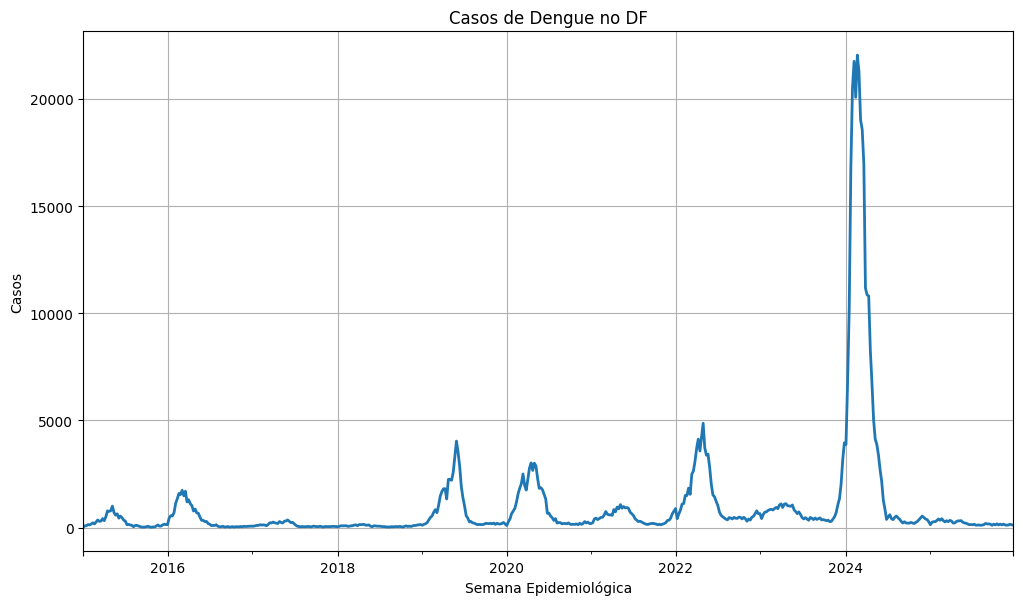

In [3]:
df_data = data[data.uf == 'DF']
fig = plt.figure(figsize=(12, 6.75))
df_data.set_index('ds')['casos'].plot(linewidth=2)
plt.grid()
plt.title('Casos de Dengue no DF')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Casos')
plt.show()

## Organiza dataset como séries hierárquicas

In [36]:
from hierarchicalforecast.utils import aggregate

data = data.rename(columns={"casos": "y"})

hiers = [
    ['pais'],
    ['pais', 'regiao'],
    # ['pais', 'regiao', 'uf']
]

hier_df, S_df, tags_df = aggregate(data, hiers)

hier_df

,unique_id,ds,y
0,Brasil,2015-01-04,760.0
1,Brasil,2015-01-11,14763.0
2,Brasil,2015-01-18,18948.0
3,Brasil,2015-01-25,26454.0
4,Brasil,2015-02-01,36286.0
...,...,...,...
3439,Brasil/Sul,2025-11-30,994.0
3440,Brasil/Sul,2025-12-07,857.0
3441,Brasil/Sul,2025-12-14,771.0
3442,Brasil/Sul,2025-12-21,824.0


In [37]:
print("Níveis hierárquicos disponíveis:")
for uid in hier_df.unique_id.unique():
    print(f"  {uid}")

Níveis hierárquicos disponíveis:
  Brasil
  Brasil/Centro-Oeste
  Brasil/Nordeste
  Brasil/Norte
  Brasil/Sudeste
  Brasil/Sul


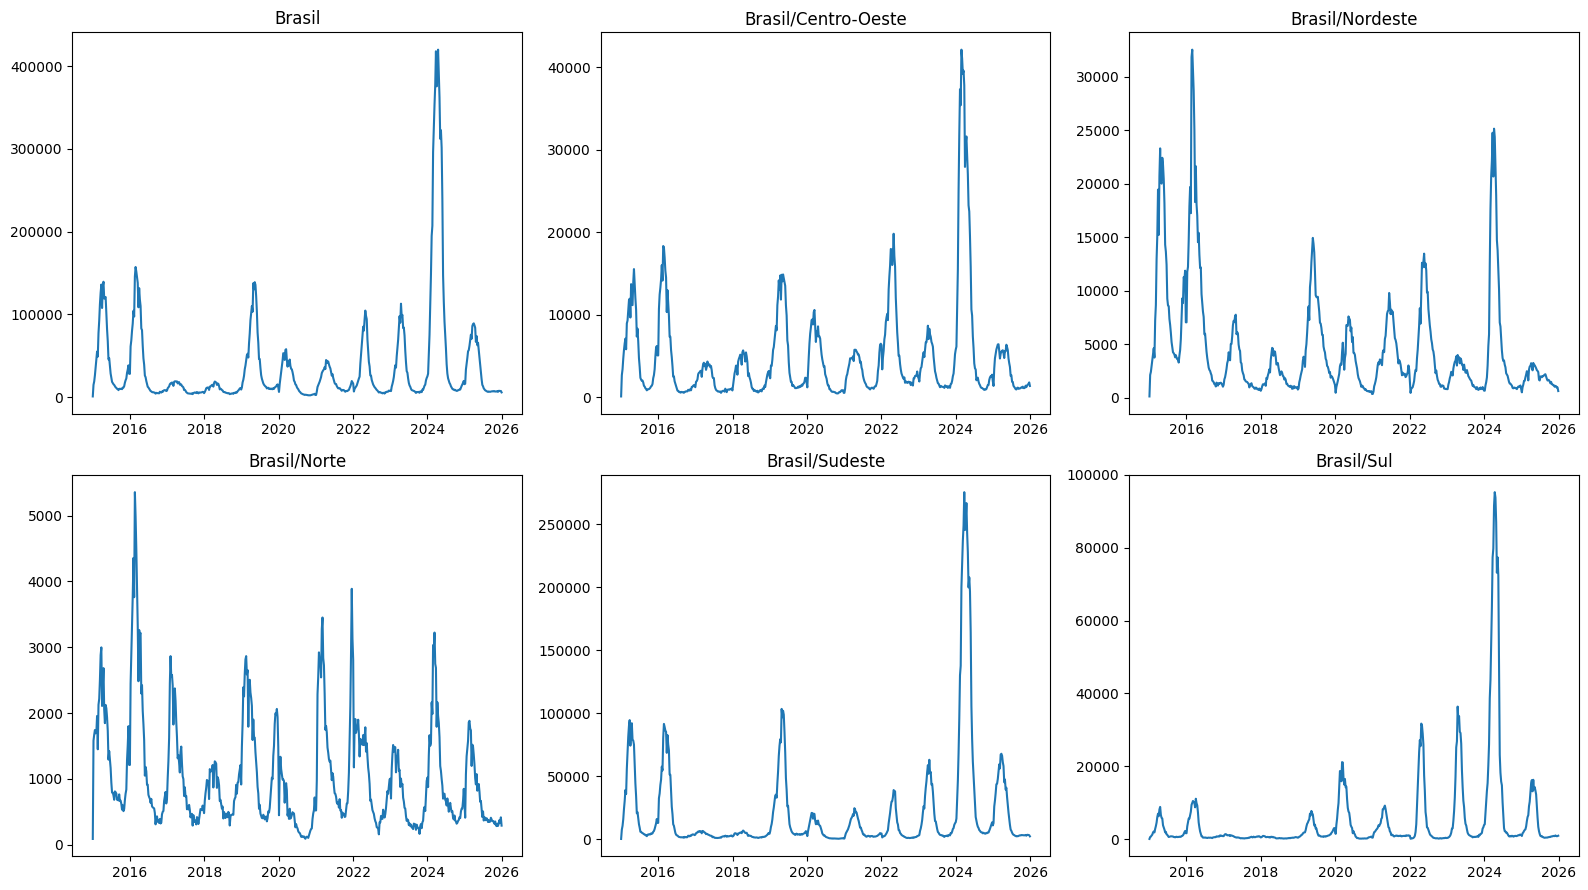

In [38]:
groups = [
    'Brasil', 'Brasil/Centro-Oeste', 'Brasil/Nordeste', 'Brasil/Norte', 'Brasil/Sudeste', 'Brasil/Sul'
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()

for i, group in enumerate(groups):
    df_group = hier_df[hier_df.unique_id == group]
    ax = axes[i]
    ax.plot(df_group["ds"], df_group["y"], label="Observado")
    ax.set_title(group)

plt.tight_layout()
plt.show()

# Previsão das séries hierárquicas

### Split Treino e Teste

In [39]:
FORECAST_HORIZON = 52  # semanas

test_df  = hier_df.groupby("unique_id", as_index=False).tail(FORECAST_HORIZON)
train_df = hier_df.drop(test_df.index).reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nTreino: {train_df.ds.min().date()} → {train_df.ds.max().date()}")
print(f"Teste : {test_df.ds.min().date()} → {test_df.ds.max().date()}")
print(f"Horizonte: {FORECAST_HORIZON} semanas")


Treino: 2015-01-04 → 2024-12-29
Teste : 2025-01-05 → 2025-12-28
Horizonte: 52 semanas


## Previsão

### StatsForecast - AutoARIMA + AutoTheta + AutoETS (juntos)

In [40]:
from statsforecast.core import StatsForecast
from statsforecast.models import AutoARIMA, AutoTheta, AutoETS

sf = StatsForecast(
    models=[
        AutoARIMA(),
        AutoTheta(),
        AutoETS(),
    ],
    freq="W-SUN",
    # n_jobs=-1,       # paraleliza por série
    verbose=True,
)

sf.fit(train_df)

sf_fcst_df = sf.forecast(
    df=train_df,
    h=FORECAST_HORIZON,
    fitted=True,          # necessário para forecast_fitted_values()
)
sf_insample_df = sf.forecast_fitted_values()

# Junta valores reais do teste
sf_fcst_df = pd.merge(sf_fcst_df, test_df[["unique_id", "ds", "y"]], on=["unique_id", "ds"])

print("\nPrevisões StatsForecast:")
print(sf_fcst_df.head())

Forecast: 100%|██████████| 6/6 [00:09<00:00,  1.55s/it]


Previsões StatsForecast:
  unique_id         ds     AutoARIMA     AutoTheta       AutoETS        y
0    Brasil 2025-01-05  18917.013833  15623.554260  15642.841943  16134.0
1    Brasil 2025-01-12  22286.779378  15624.712692  15642.841943  33223.0
2    Brasil 2025-01-19  25061.930782  15625.856317  15642.841943  39937.0
3    Brasil 2025-01-26  27034.381104  15626.985279  15642.841943  47287.0
4    Brasil 2025-02-02  31682.929781  15628.099721  15642.841943  55300.0


### MLForecast - XGBoost


In [41]:
from mlforecast import MLForecast
from xgboost import XGBRegressor

ml = MLForecast(
    models={"XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)},
    freq='W-SUN',
    lags=[1, 4, 8, 13, 26, 52],
    date_features=["week", "month"],
)

ml.fit(train_df, fitted=True)

ml_fcst_df = ml.predict(FORECAST_HORIZON)
ml_insample_df = ml.forecast_fitted_values()

# Garante colunas compatíveis com StatsForecast
ml_fcst_df = pd.merge(ml_fcst_df, test_df[["unique_id", "ds", "y"]], on=["unique_id", "ds"])

print("\nPrevisões MLForecast:")
print(ml_fcst_df.head())


Previsões MLForecast:
  unique_id         ds       XGBoost        y
0    Brasil 2025-01-05  14445.495117  16134.0
1    Brasil 2025-01-12  14342.279297  33223.0
2    Brasil 2025-01-19  16456.701172  39937.0
3    Brasil 2025-01-26  16122.669922  47287.0
4    Brasil 2025-02-02  15909.908203  55300.0


# Reconciliação

In [42]:
# Merge de todas as previsões base numa tabela só
all_fcst_df = sf_fcst_df.merge(
    ml_fcst_df[["unique_id", "ds", "XGBoost"]],
    on=["unique_id", "ds"],
    how="left",
)
 
# Insample: une StatsForecast + MLForecast
all_insample_df = sf_insample_df.merge(
    ml_insample_df[["unique_id", "ds", "XGBoost"]],
    on=["unique_id", "ds"],
    how="left",
).dropna()
 
print("Colunas de previsão base:", [c for c in all_fcst_df.columns if c not in ("unique_id", "ds", "y")])

Colunas de previsão base: ['AutoARIMA', 'AutoTheta', 'AutoETS', 'XGBoost']


In [43]:
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import BottomUp, MinTrace, TopDown

# definir modelos de reconciliação
# Reconciliação
reconcilers = [
    BottomUp(),
    MinTrace(method="mint_shrink"),
    TopDown(method="forecast_proportions"),
]
hrec = HierarchicalReconciliation(reconcilers)

rec_df = hrec.reconcile(
    Y_hat_df=all_fcst_df,
    Y_df=all_insample_df,
    S_df=S_df,
    tags=tags_df,
)
 
print("\nDataframe reconciliado – colunas:")
print([c for c in rec_df.columns if c not in ("unique_id", "ds")])


Dataframe reconciliado – colunas:
['AutoARIMA', 'AutoTheta', 'AutoETS', 'y', 'XGBoost', 'AutoARIMA/BottomUp', 'AutoTheta/BottomUp', 'AutoETS/BottomUp', 'XGBoost/BottomUp', 'AutoARIMA/MinTrace_method-mint_shrink', 'AutoTheta/MinTrace_method-mint_shrink', 'AutoETS/MinTrace_method-mint_shrink', 'XGBoost/MinTrace_method-mint_shrink', 'AutoARIMA/TopDown_method-forecast_proportions', 'AutoTheta/TopDown_method-forecast_proportions', 'AutoETS/TopDown_method-forecast_proportions', 'XGBoost/TopDown_method-forecast_proportions']


# Avaliação

In [44]:
from hierarchicalforecast.evaluation import evaluate as hevaluate
from utilsforecast.losses import rmse, mape

eval = hevaluate(
    df = rec_df,
    tags=tags_df,
    metrics=[mape],
)
eval.T

,0,1,2
level,pais,pais/regiao,Overall
metric,mape,mape,mape
AutoARIMA,4.252759,3.6668,3.76446
AutoTheta,0.928415,0.80674,0.827019
AutoETS,0.927212,0.872187,0.881358
XGBoost,0.624829,0.736823,0.718158
AutoARIMA/BottomUp,3.869881,3.6668,3.700647
AutoTheta/BottomUp,0.919578,0.80674,0.825547
AutoETS/BottomUp,0.944151,0.872187,0.884181
XGBoost/BottomUp,0.392961,0.736823,0.679513


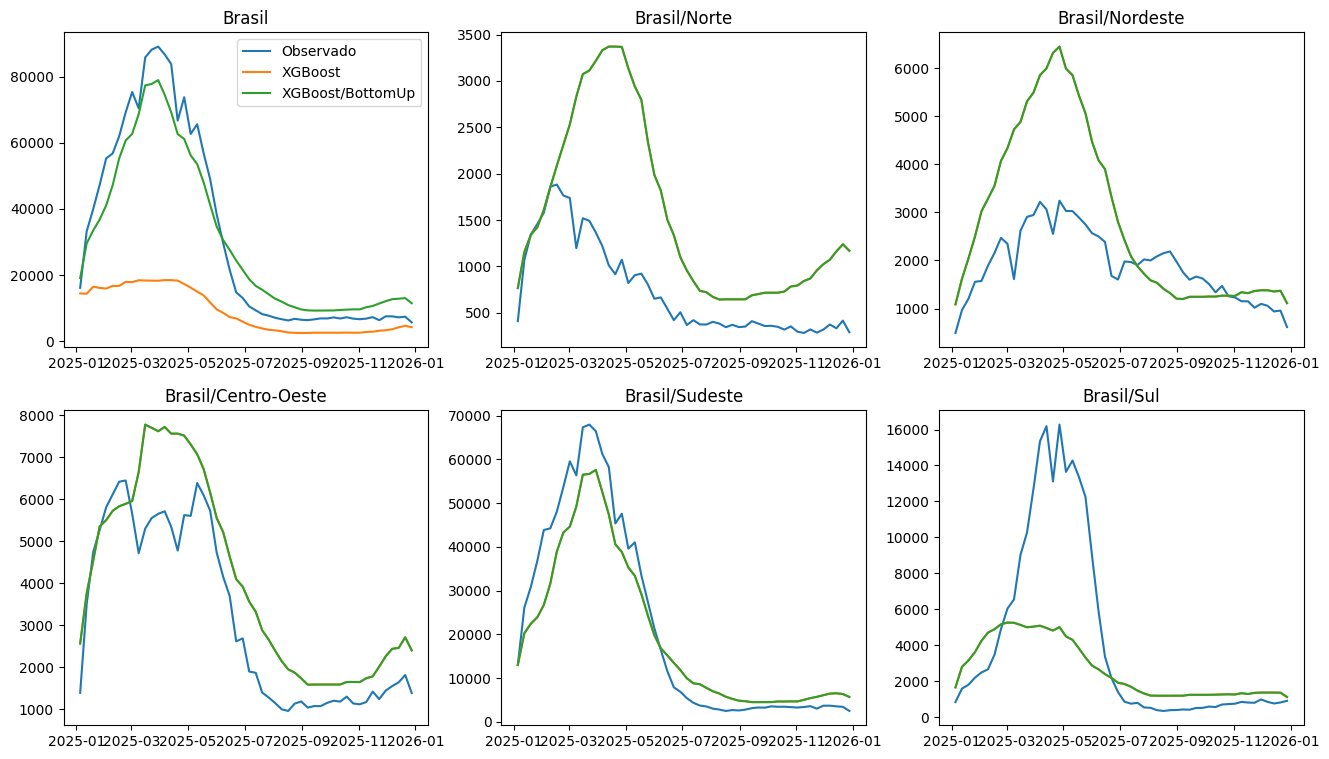

In [45]:
groups = [
    'Brasil',
    'Brasil/Norte',
    'Brasil/Nordeste',
    'Brasil/Centro-Oeste',
    'Brasil/Sudeste',
    'Brasil/Sul',
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 9))
axes = axes.flatten()

for i, group in enumerate(groups):
    df_group = rec_df[rec_df.unique_id == group]
    ax = axes[i]
    ax.plot(df_group['ds'], df_group['y'], label='Observado')
    ax.plot(df_group['ds'], df_group['XGBoost'], label='XGBoost')
    ax.plot(df_group['ds'], df_group['XGBoost/BottomUp'], label='XGBoost/BottomUp')
    ax.set_title(group)
    if i == 0:
        ax.legend()
plt.show()